In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np





Merging Datasets

In [135]:
import pandas as pd

#Importing both datasets
BNPL = pd.read_csv('../Data/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')
Salary = pd.read_csv('../Data/usa_col_salary_longitudinal_2010_2024.csv')



In [136]:
BNPL.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


In [137]:
Salary.head()

,year,city,state,city_tier,population_approx,median_salary_gross_usd_monthly,median_salary_net_usd_monthly,median_salary_gross_usd_annual,national_median_gross_usd_monthly,national_median_gross_usd_annual,...,cost_of_living_index,rent_1br_city_center_usd,rent_1br_outside_center_usd,meal_cheap_restaurant_usd,groceries_monthly_usd,public_transport_monthly_usd,est_monthly_cost_single_usd,affordability_ratio,rent_to_income_pct,data_source
0,2010,New York City,New York,megalopolis,8300000,3690,2694,44280,2820,33840,...,95.5,2750,1972,15,424,93,2893,0.93,53.4,numbeo
1,2011,New York City,New York,megalopolis,8300000,3850,2810,46200,2872,34460,...,95.7,2862,1934,15,419,93,2854,0.98,50.2,numbeo
2,2012,New York City,New York,megalopolis,8300000,3893,2842,46716,2896,34750,...,96.0,2692,2045,17,424,98,3017,0.94,52.5,numbeo
3,2013,New York City,New York,megalopolis,8300000,3830,2796,45960,2923,35080,...,97.5,2748,2171,17,463,98,3184,0.88,56.7,numbeo
4,2014,New York City,New York,megalopolis,8300000,4092,2987,49104,2962,35540,...,97.6,2736,2116,16,449,98,3096,0.96,51.7,numbeo


Checking Columns

In [138]:
BNPL.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment'],
      dtype='str')

In [139]:
#Keeping only columns needed for research
BNPL_clean = BNPL[['age', 'monthly_income', 'credit_score',
       'repayment_delay_days', 'missed_payments',
        'location', 
       'debt_to_income_ratio', 'risk_score', 'customer_segment']]

In [140]:
Salary.columns

Index(['year', 'city', 'state', 'city_tier', 'population_approx',
       'median_salary_gross_usd_monthly', 'median_salary_net_usd_monthly',
       'median_salary_gross_usd_annual', 'national_median_gross_usd_monthly',
       'national_median_gross_usd_annual', 'national_mean_gross_usd_monthly',
       'fed_min_wage_usd_hourly', 'salary_to_national_ratio', 'cpi_annual_pct',
       'cost_of_living_index', 'rent_1br_city_center_usd',
       'rent_1br_outside_center_usd', 'meal_cheap_restaurant_usd',
       'groceries_monthly_usd', 'public_transport_monthly_usd',
       'est_monthly_cost_single_usd', 'affordability_ratio',
       'rent_to_income_pct', 'data_source'],
      dtype='str')

Filtering 

In [141]:

#Filetering columns I want to keep
Salary_clean = Salary[['year', 'state', 'cost_of_living_index','median_salary_gross_usd_monthly',
             'median_salary_net_usd_monthly', 'salary_to_national_ratio']]

###Research Questions
Do the majority of BNPL users fall into lower credit score brackets?
Which states show the highest risk
Is there a relationship between cost of living index, monthly salary, and BNPL usage

In [142]:
print(BNPL_clean['location'].unique()[:10])
print(Salary_clean['state'].unique()[:10])

<StringArray>
['Australia', 'USA', 'Germany', 'India', 'Canada', 'UK']
Length: 6, dtype: str
<StringArray>
[      'New York',  'Massachusetts',    'Connecticut',   'Rhode Island',
     'New Jersey',   'Pennsylvania',       'Maryland',             'DC',
       'Virginia', 'North Carolina']
Length: 10, dtype: str


In [143]:
#filtering for USA
bnpl_usa= BNPL_clean[BNPL_clean['location'] == 'USA'].copy()

print('US BNPL rows:', bnpl_usa.shape[0])



US BNPL rows: 1736


In [144]:
# Change monthly_income to (int) from float64
BNPL['monthly_income'] = BNPL['monthly_income'].astype(int)



In [145]:
#checking for missing values
bnpl_usa.isna()

bnpl_usa.isna().sum()

age                     0
monthly_income          0
credit_score            0
repayment_delay_days    0
missed_payments         0
location                0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64

In [146]:
#checking for duplicates
Salary.duplicated(keep=False).sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1405    False
1406    False
1407    False
1408    False
1409    False
Length: 1410, dtype: bool>

In [147]:
#viewing monthly income of users
BNPL['monthly_income'].describe()

count     10345.000000
mean      35052.907105
std       27084.503349
min        5000.000000
25%       12207.000000
50%       23800.000000
75%       55276.000000
max      145767.000000
Name: monthly_income, dtype: float64

In [148]:
Salary['median_salary_gross_usd_monthly'].describe()

count    1410.000000
mean     3636.726950
std       867.360865
min      2228.000000
25%      2969.250000
50%      3482.000000
75%      4075.750000
max      7471.000000
Name: median_salary_gross_usd_monthly, dtype: float64

In [149]:
#Create a true montly income column by dividing the annual values by 12
bnpl_usa['true_monthly_income'] = bnpl_usa['monthly_income'] / 12

#Checking new  stats
bnpl_usa['true_monthly_income'].describe()

count     1736.000000
mean      2921.139277
std       2283.206066
min        416.666667
25%       1004.246250
50%       1965.609583
75%       4676.928125
max      11556.224167
Name: true_monthly_income, dtype: float64

***The average US BNPL user makes signigicantly less money per month, then overall median state salary

In [150]:
BNPL['credit_score'].value_counts()

credit_score
300    1373
341      54
308      53
320      51
337      50
       ... 
809       1
846       1
795       1
766       1
808       1
Name: count, Length: 534, dtype: int64

In [151]:
BNPL['age'].value_counts()

age
26    274
51    268
53    266
35    266
20    265
55    262
21    261
45    260
28    260
24    259
40    259
57    257
50    255
43    252
54    251
59    251
31    251
39    250
46    250
33    248
49    248
52    247
27    247
19    244
32    244
44    243
42    243
22    242
48    239
30    238
36    236
37    234
29    233
47    231
38    231
25    231
56    227
58    227
34    225
41    225
23    223
18    222
Name: count, dtype: int64

Creating 3 Unique Functions

In [152]:
# 1st Function
# This function groups BNPL users into 3 credit score categories: Low, Medium, and High.
# For each group, it calculates the average number of missed payments.
# This helps answer the question: "Do users with lower credit scores tend to miss more payments?"

def average_missed_payments_by_credit_score(df):
    
#Groups users into 3 simple credit score groups (Low, Medium, High)
#and shows the average number of missed payments in each group.
    
    # column that labels each user's credit score group
    def get_group(score):
        if score < 580:
            return "Low"
        elif score < 700:
            return "Medium"
        else:
            return "High"

    df["credit_group"] = df["credit_score"].apply(get_group)

    # Group by that label and get the average missed payments
    result = df.groupby("credit_group")["missed_payments"].mean()

    return result

result = average_missed_payments_by_credit_score(BNPL)
result

credit_group
High      0.646655
Low       1.072014
Medium    0.846467
Name: missed_payments, dtype: float64

Those with low credit scores missed the most payments...makes sense

In [153]:
#Funtion 2
# Flag High Risk Users
#identifying users whose risk score is 70 or higher

def flag_high_risk_users(df, risk_threshold=70):

#Adding a column that labels each user as 'High Risk' or 'Low Risk'
#based on whether their risk_score is above a threshold.
#using lambda instead of  if/else statement
    
    df["risk_flag"] = df["risk_score"].apply(
        lambda score: "High Risk" if score >= risk_threshold else "Low Risk"
    )
    return df

#show top five results
BNPL = flag_high_risk_users(BNPL, risk_threshold=70)
BNPL[["user_id", "risk_score", "risk_flag"]].head()



,user_id,risk_score,risk_flag
0,1,165.2,High Risk
1,2,266.0,High Risk
2,3,229.6,High Risk
3,4,356.0,High Risk
4,5,135.2,High Risk


In [154]:
#Show all results of high risk and low risk

BNPL["risk_flag"].value_counts()

risk_flag
High Risk    9942
Low Risk      403
Name: count, dtype: int64

In [155]:
#Function 3

def average_purchase_by_category(df):

    #Calculates the average purchase amount for each product category.
    #Helps identify which categories has the largest BNPL purchases.
    
    result = df.groupby("product_category")["purchase_amount"].mean()
    return result

result3 = average_purchase_by_category(BNPL)
print(result3)

product_category
Beauty         3932.568818
Electronics    4039.981568
Fashion        3975.760222
Home           3962.608382
Sports         3986.044645
Name: purchase_amount, dtype: float64


Visualation

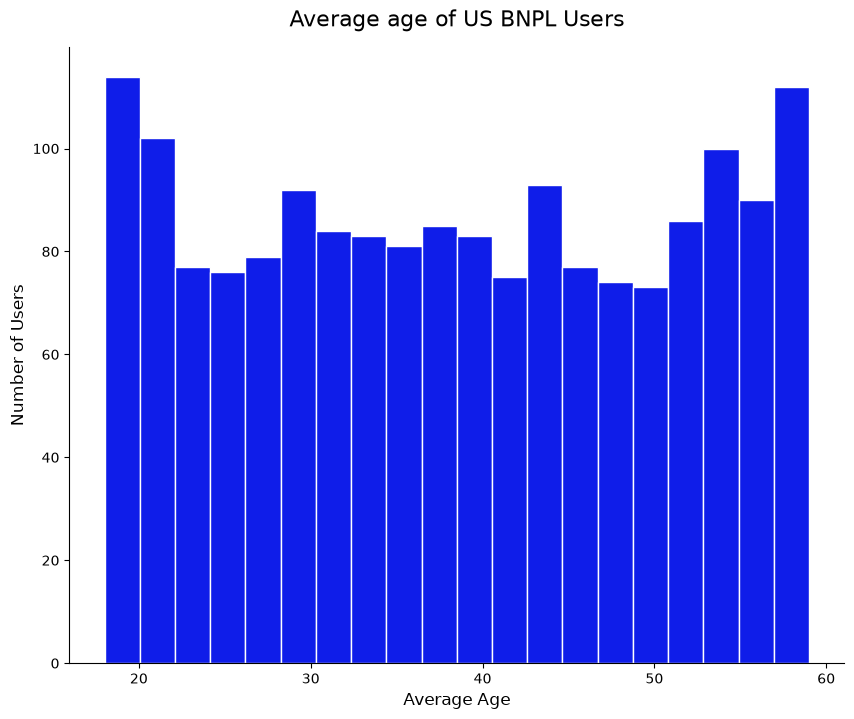

In [156]:
#Which age group are at the hightest risk 
#Visualation (Histogram)


plt.figure(figsize=(10,8))
plt.hist(
    bnpl_usa["age"],
    bins=20,
    color="#0f1de9",
    edgecolor = "white"
)


plt.xlabel("Average Age", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.title("Average age of US BNPL Users", fontsize=16, pad=15)

ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Display the plot
plt.show()
    

###Age demo of BNPL users
I used a bold blue color with white edges to give a cleaner look

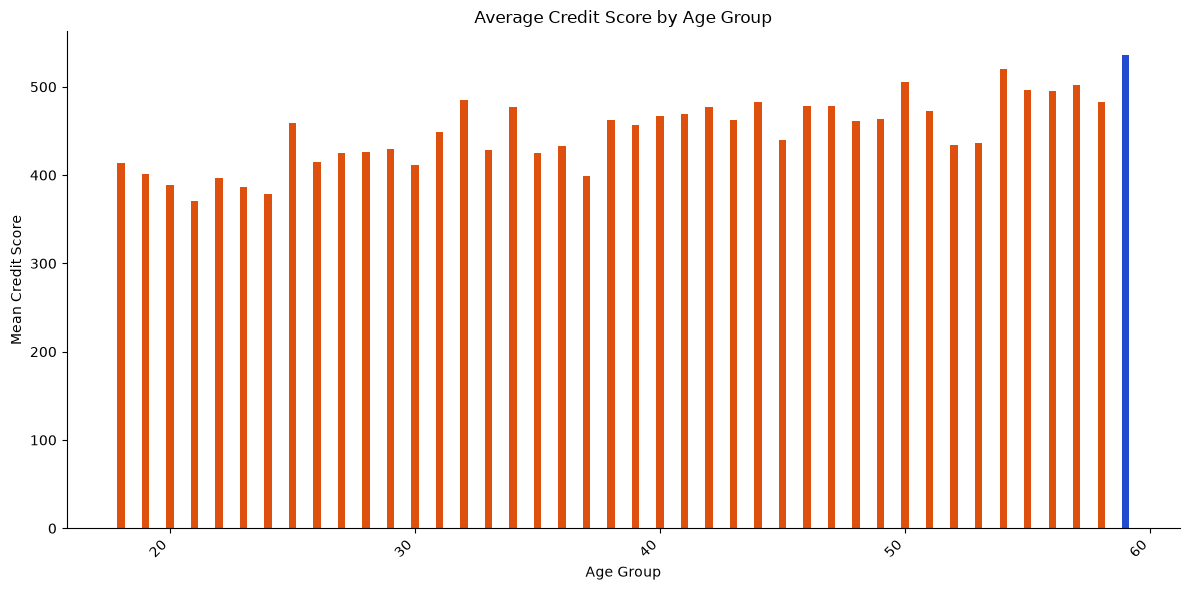

In [157]:
#Grouping by age and calculating the mean credit score
avg_credit_by_age = bnpl_usa.groupby('age')['credit_score'].mean().reset_index()

#Plot and default color
plt.figure(figsize=(12,6))
colors = ["#dd500e"]*len(avg_credit_by_age)

#Bar Color
max_index = avg_credit_by_age['credit_score'].idxmax()
highlight_position = avg_credit_by_age.index.get_loc(max_index)
colors[max_index] = "#123eccee"

plt.bar(avg_credit_by_age['age'], avg_credit_by_age['credit_score'], color = colors, width =0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Age Group")
plt.ylabel("Mean Credit Score")
plt.title("Average Credit Score by Age Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

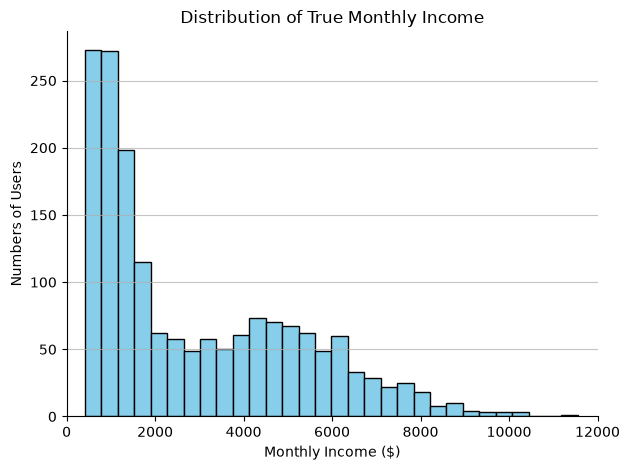

In [158]:
#Plotting a histogram of the true monthly income
plt.hist(bnpl_usa['true_monthly_income'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of True Monthly Income')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Numbers of Users')

#centering the view on where 99% of users sit
plt.xlim(0, 12000)

plt.grid(axis='y', alpha=0.75)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

***I choose a histogram to visualize the density and spread of user incomes after correcting the column from annual to monthly value
**Finding:The chart reveals a heavily right-skewed distrubution. Users heavily clusters under $3000 a month
BNPL services are being used by lower income population

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
import sqlite3
 
conn = sqlite3.connect("bnpl_project.db")
cursor = conn.cursor()